# Python PostgreSQL

## Prerequisites
First, install the Python adapter for PostgreSQL with:

> pip install psycopg

Then, create a "postgress" database using pgAdmin, and in it, create a "demo" user with:

> CREATE USER demo WITH PASSWORD '1234';

In [ ]:
# %pip install psycopg


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import psycopg

## A Quick Introduction to PostgreSQL with Python

- **First**, connect to the database using the database library's `connect` method.
- **Second**, get a `cursor` which will let us execute SQL commands
- **Third**, We can now execute any SQL commands that we want in the database using the cursor's `execute` method. Querying the database simply involves writing the appropriate SQL and placing it inside a string in the `execute` method call.

### Connecting to a DB

In [54]:
con = psycopg.connect(
    host="localhost",
    dbname="postgres",
    user="demo",
    password="1234"
)

In [29]:
password = "1234"
user = "demo"

Cursor object using the cursor method of the Connection object.

In [55]:
cur = con.cursor()

In [35]:
# con.rollback()

In [56]:
cur.execute('''DROP TABLE IF EXISTS test;
CREATE TABLE test (
    i NUMERIC,
    j VARCHAR(50)
)''')

<psycopg.Cursor [COMMAND_OK] [INTRANS] (host=localhost user=demo database=postgres) at 0x10a1ef950>

In [57]:
con.commit()  # Make the changes to the database persistent

- Note this takes care of putting quotes around the second parameter, appropriately escape the quote mark in it and is generally safer from SQL injection.
- Note you have to use %% for the modulo operator when using parameters.
- Note you use %s **regardless of the type** of the parameter

In [58]:
n = 5
m = "I'm using Psycopg"
#INSERT INTO test(i,j) VALUES (5,'I\'m using Psycopg') - NOT SAFE
cur.execute('INSERT INTO test(i,j) VALUES (%s,%s)', (n,m))  

<psycopg.Cursor [COMMAND_OK] [INTRANS] (host=localhost user=demo database=postgres) at 0x10a1ef950>

In [59]:
con.commit()  # Note we commit via the connection, not via the cursor

SQL injection example (not in this course material):

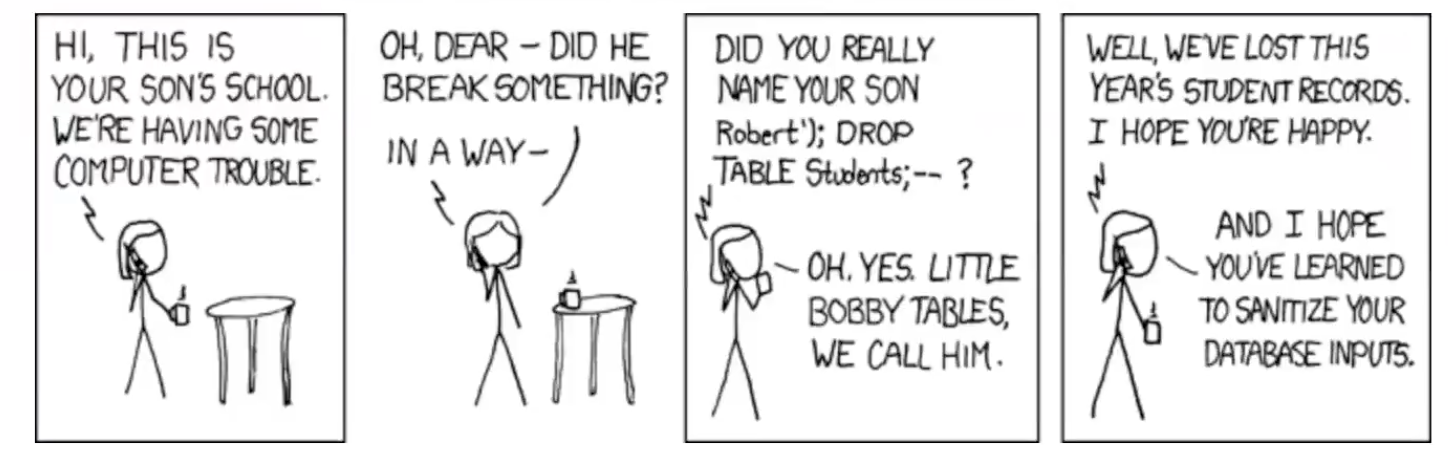

In [60]:
# Another option
n = 100
m = 'more text'
# tuple
cur.execute('INSERT INTO test(i,j) VALUES (%(a)s,%(m)s)', {'a': n, 'm': m})
con.commit()

### Fetching Data

In [61]:
cur.execute('SELECT * FROM test')

<psycopg.Cursor [TUPLES_OK] [INTRANS] (host=localhost user=demo database=postgres) at 0x10a1ef950>

In [62]:
results = cur.fetchall()
print(results)

[(Decimal('5'), "I'm using Psycopg"), (Decimal('100'), 'more text')]


In [63]:
for i, j in results:
    print(i, j)

5 I'm using Psycopg
100 more text


In [64]:
cur.execute('SELECT * FROM test WHERE i=5')
print(cur.fetchall())

[(Decimal('5'), "I'm using Psycopg")]


In [65]:
cur.execute("UPDATE test SET j='yet more test' WHERE i=5")
cur.execute('SELECT * FROM test')
print(cur.fetchall())

[(Decimal('100'), 'more text'), (Decimal('5'), 'yet more test')]


In [66]:
cur.execute('DELETE FROM test WHERE i=5')
con.commit()

In [67]:
cur.execute('SELECT * FROM test')
print(cur.fetchall())

[(Decimal('100'), 'more text')]


When we finish, we need to remember to **manually** close the connection to the database.

In [68]:
cur.close()
con.close()

Another way is to use the `with` statement. The connection and cursor will close **automatically** when the block exits, even if an error occurs.
```python
import psycopg

# Connect to the database
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as conn:
    
    # Open a cursor to perform database operations
    with conn.cursor() as cur:
        cur.execute("SELECT * FROM my_table")
        results = cur.fetchall()
        
        # Cursor closes automatically here

# Connection closes automatically here
```

## PostgreSQL Basic Tutorial

### 1. Inserting and Quering Data

In [69]:
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    with con.cursor() as cur:
        cur.execute("DROP TABLE IF EXISTS Cars")
        cur.execute("CREATE TABLE Cars(Id NUMERIC, Name VARCHAR(10), Price NUMERIC)")
        cur.execute("INSERT INTO Cars VALUES(1,'Audi',52642)")
        cur.execute("INSERT INTO Cars VALUES(2,'Mercedes',57127)")
        cur.execute("INSERT INTO Cars VALUES(3,'Skoda',9000)")
        cur.execute("INSERT INTO Cars VALUES(4,'Volvo',29000)")
        cur.execute("INSERT INTO Cars VALUES(5,'Bentley',350000)")
        cur.execute("INSERT INTO Cars VALUES(6,'Citroen',21000)")
        cur.execute("INSERT INTO Cars VALUES(7,'Hummer',41400)")
        cur.execute("INSERT INTO Cars VALUES(8,'Volkswagen',21600)")
# No need to call con.commit(). Exiting the with block commits the transaction unless an exception was raised.

In Python, we can use the `fetchall()` method to fetch all the records in the table.
Lets fetch all records from the `Cars` table:

In [70]:
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    with con.cursor() as cur:
        cur.execute('SELECT * FROM Cars')

        # rows = cur.fetchall()

        # for row in rows:
        #     print(row)

        # or, you can do also:
        print(cur.fetchall())

[(Decimal('1'), 'Audi', Decimal('52642')), (Decimal('2'), 'Mercedes', Decimal('57127')), (Decimal('3'), 'Skoda', Decimal('9000')), (Decimal('4'), 'Volvo', Decimal('29000')), (Decimal('5'), 'Bentley', Decimal('350000')), (Decimal('6'), 'Citroen', Decimal('21000')), (Decimal('7'), 'Hummer', Decimal('41400')), (Decimal('8'), 'Volkswagen', Decimal('21600'))]


Or, alternatively, to get the results into Python we then use either the `fetchone()` method to fetch one record at a time (it returns None when there are no more records to fetch so that you know when to stop)

In [71]:
con = psycopg.connect(host="localhost", dbname="postgres", user=user, password=password)
cur = con.cursor()

cur.execute('SELECT * FROM Cars')
record = cur.fetchone()

while record is not None:
    print(record)
    record = cur.fetchone()

cur.close()
con.close()

(Decimal('1'), 'Audi', Decimal('52642'))
(Decimal('2'), 'Mercedes', Decimal('57127'))
(Decimal('3'), 'Skoda', Decimal('9000'))
(Decimal('4'), 'Volvo', Decimal('29000'))
(Decimal('5'), 'Bentley', Decimal('350000'))
(Decimal('6'), 'Citroen', Decimal('21000'))
(Decimal('7'), 'Hummer', Decimal('41400'))
(Decimal('8'), 'Volkswagen', Decimal('21600'))


Another possiblity ...

In [72]:
con = psycopg.connect(host="localhost", dbname="postgres", user=user, password=password)

with con:
    with con.cursor() as cur:
        cur.execute("SELECT * FROM Cars")
        rows = cur.fetchall()

for row in rows:
    print(row[0], row[1], row[2])

1 Audi 52642
2 Mercedes 57127
3 Skoda 9000
4 Volvo 29000
5 Bentley 350000
6 Citroen 21000
7 Hummer 41400
8 Volkswagen 21600


Select all the cars that cost more than 35000: (Class Exercise)

In [23]:
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    with con.cursor() as cur:
        cur.execute("""SELECT *
        FROM cars
        WHERE price > 35000""")

        print(cur.fetchall())
        print(cur.fetchone()) # will print None since we fetched all the rows already

[(1, 'Audi', 52642), (2, 'Mercedes', 57127), (5, 'Bentley', 350000), (6, 'Hummer', 41400)]
None


We are going to create the same table. This time using the convenience `executemany()` method.

In [73]:
cars = [
    (1, 'Audi', 52642),
    (2, 'Mercedes', 57127),
    (3, 'Skoda', 9000),
    (4, 'Volvo', 29000),
    (5, 'Bentley', 350000),
    (6, 'Hummer', 41400),
    (7, 'Volkswagen', 21600)
]

con = psycopg.connect(host="localhost",dbname="postgres", user=user, password=password)

with con:
    with con.cursor() as cur:
        # This script drops a Cars table if it exists and (re)creates it.
        cur.execute("DROP TABLE IF EXISTS Cars")
        cur.execute("CREATE TABLE Cars(Id INT, Name TEXT, Price INT)")
        cur.executemany("INSERT INTO Cars VALUES(%s, %s, %s)", cars)

## 2. Parameterized queries

When we use parameterized queries, we use placeholders instead of directly writing the values into the statements. Parameterized queries increase security and performance.

The Python **PostgreSQL** module supports two types of placeholders. Question marks and named placeholders.

In [ ]:
uId = 1
uPrice = 62300

In [ ]:
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    with con.cursor() as cur:
        cur.execute("UPDATE cars SET price=%s WHERE id=%s", (uPrice, uId))
        print(f"Number of rows updated: {cur.rowcount}")

Number of rows updated: 1


The next example uses parameterized statements with named placeholders:

In [ ]:
uId = 4

with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    with con.cursor() as cur:
        cur.execute("SELECT * FROM Cars WHERE Id=%(Id)s", {"Id": uId})
        row = cur.fetchone()

print(row[0], row[1])

4 Volvo


## 3. Metadata

Next we will print all rows from the Cars table with their column names.

In [74]:
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    with con.cursor() as cur:
        cur.execute('SELECT * FROM Cars ORDER BY price')
        print(cur.description)
        col_names = [col[0] for col in cur.description]
        rows = cur.fetchall()

print("%-5s %-15s %s" % (col_names[0], col_names[1], col_names[2]))

for row in rows:
    print( "%-5s %-15s %s" % row)

[<Column 'id', type: int4 (oid: 23)>, <Column 'name', type: text (oid: 25)>, <Column 'price', type: int4 (oid: 23)>]
id    name            price
3     Skoda           9000
7     Volkswagen      21600
4     Volvo           29000
6     Hummer          41400
1     Audi            52642
2     Mercedes        57127
5     Bentley         350000


## 4. Error Handling

In [76]:
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    # Successfull transactions are committed automatically.
    with con.cursor() as cur:
        cur.execute("DROP TABLE IF EXISTS person")
        cur.execute("CREATE TABLE person (id NUMERIC PRIMARY KEY, firstname VARCHAR(20) UNIQUE)")
        cur.execute("INSERT INTO person(id, firstname) VALUES (%s, %s)", (1, "Joe"))
        cur.execute("INSERT INTO person(id, firstname) VALUES (%s, %s)", (2, "Joe2"))
        cur.execute("INSERT INTO person(id, firstname) VALUES (%s, %s)", (3, "Joe3"))
    
    # con.rollback() is called automatically if an exception is raised after
    # the 'with con:' block finishes with an exception.
    
with psycopg.connect(host="localhost", dbname="postgres", user=user, password=password) as con:
    try:
        with con.cursor() as cur:
            cur.execute("INSERT INTO person(id, firstname) VALUES (%s, %s)", (44, "Joe4"))
            cur.execute("INSERT INTO person(id, firstname) VALUES (%s, %s)", (4, "Joe")) 
                
    except psycopg.IntegrityError:
        print("Couldn't add Joe twice. Transaction rolled back automatically.")
        raise
        # The 'with con:' block caught the error, rolled back, and re-raised it.
        # We catch it here to print a message, but the DB is already clean.

Couldn't add Joe twice. Transaction rolled back automatically.


UniqueViolation: duplicate key value violates unique constraint "person_firstname_key"
DETAIL:  Key (firstname)=(Joe) already exists.

In [ ]:
con = psycopg.connect(host="localhost", dbname="postgres", user=user, password=password)
try:
    with con.cursor() as cur:
        cur.execute("create table person (id NUMERIC primary key, firstname varchar(20) unique)")
        cur.execute("insert into person(id, firstname) values (%s,%s)", (1, "Joe"))
        cur.execute("insert into person(id, firstname) values (%s, %s)", (2, "Joe2"))
        cur.execute("insert into person(id, firstname) values (%s, %s)", (3, "Joe3"))

except (Exception, psycopg.DatabaseError) as error:
    print(error)
    #raise
finally:
    if con is not None:
        con.close()

relation "person" already exists


## 5. Transactions


In psycopg 3, if we used the "with" statement to open a connection, we don't need to close it explicitly. And if we will try using the same connection in another "with" block, we will get an error.

In [77]:
con = psycopg.connect(host="localhost", dbname="postgres", user=user, password=password)

# transaction 1
with con:
    with con.cursor() as cur:
        cur.execute('SELECT * from test')

# transaction 2
with con:
    with con.cursor() as cur:
        cur.execute('SELECT * from test')

OperationalError: the connection is closed